In [1]:
import numpy as np
import pandas as pd
import os,sys,glob
%load_ext autoreload
%autoreload 2
import plotting_helpers as helper
import nibabel as nib
import scipy
import nilearn
from scipy.spatial.distance import cdist, pdist, squareform
import stats_helpers
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from nilearn.maskers import NiftiMasker
from nilearn.mass_univariate import permuted_ols
import partlycloudy_utils as pcu
import partlycloudy_config as pcc
from scipy import stats
from scipy.stats import wilcoxon
from obspy.imaging.cm import viridis_white



In [2]:

# # Load and combine the CSV files from the Partly Cloudy dataset
# fns = glob.glob(f'{pcu.get_results_dir()}/*average_results_atlas_aggregated.csv')
# dataframes = []
# for f in fns:
#     a = pd.read_csv(f, index_col=0)
#     # Determine measure type from filename
#     if 'ISC' in f:
#         a['measure'] = 'ISC'
#         a['score'] = a['score']
#     elif 'TPHATE_DiffOp_IDE' in f:
#         a['measure'] = 'TPHATE_DiffOp'
#         a['score'] = a['id_estimate']
#     else:  # 'PCA' in f:
#         a['measure'] = 'PCA'
#         a['score'] = a['id_estimate']
    
#     # Keep relevant columns
#     a = a[["region_name","task","subject","AgeGroup","Age","measure",'score']]
#     dataframes.append(a)

# results_df = pd.concat(dataframes, ignore_index=True)
# print(f"Combined results dataframe shape: {results_df.shape}")
# print(f"Available measures: {results_df['measure'].unique()}")
# print(f"Available age groups: {results_df['AgeGroup'].unique()}")
# print(f"Number of unique subjects: {results_df['subject'].nunique()}")
# print(f"Tasks: {results_df['task'].unique()}")
# results_df.to_csv(f'{pcu.get_results_dir()}/parcelwise_results_ISC_IDE.csv', index=False)
results_df=pd.read_csv(f'{pcu.get_results_dir()}/parcelwise_results_ISC_IDE.csv')

# Exploration of participant information and demographics

Total participants in demographic file: 155
Age group distribution:
AgeGroup1
Adult    33
U05      31
U06      34
U082     26
U13      31
Name: count, dtype: int64


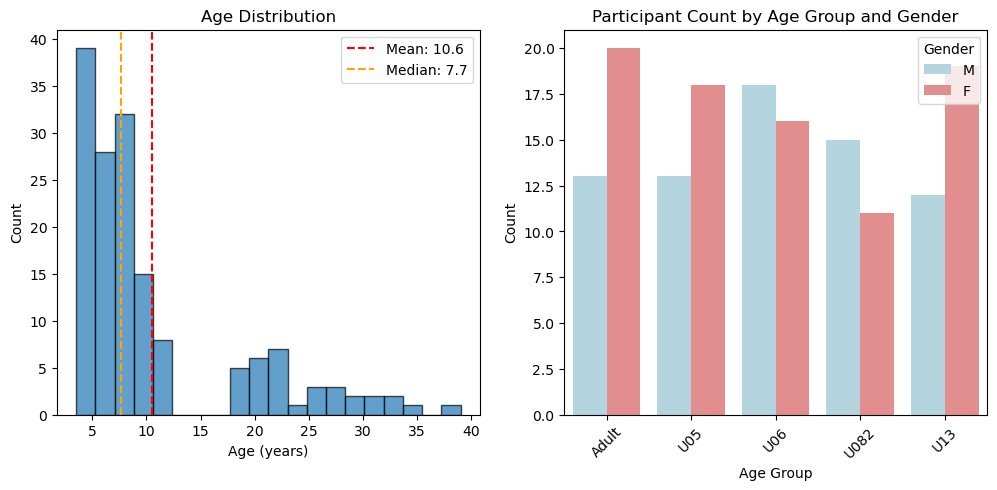

In [18]:
# Load participant demographic information
par_df = pd.read_csv('PartlyCloudy/participants.csv', index_col=0)
print(f'Total participants in demographic file: {par_df.shape[0]}')

# Create consistent age groupings 
def get_age_groupings(age):
    if age < 5:
        return 'U05'
    elif age < 6:
        return 'U06'
    elif age < 8.2:
        return 'U082'
    elif age < 13:
        return 'U13'
    else:
        return 'Adult'

par_df['AgeGroup1'] = [get_age_groupings(a) for a in par_df['Age']]
results_df['AgeGroup1'] = [get_age_groupings(a) for a in results_df['Age']]

print(f'Age group distribution:')
print(par_df['AgeGroup1'].value_counts().sort_index())

# Plot age distribution by age groups and other demographics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution histogram
ax = axes[0]
par_df['Age'].hist(bins=20, alpha=0.7, ax=ax, edgecolor='black')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Age Distribution')
ax.axvline(par_df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {par_df["Age"].mean():.1f}')
ax.axvline(par_df['Age'].median(), color='orange', linestyle='--', label=f'Median: {par_df["Age"].median():.1f}')
ax.legend()
# Turn off background grid
ax.grid(False)

# Age groups bar plot by gender
ax = axes[1]
age_order = sorted(par_df['AgeGroup1'].unique())
sns.countplot(data=par_df, x='AgeGroup1', hue='Gender', order=age_order,
              palette={'F': 'lightcoral', 'M': 'lightblue'}, ax=ax)
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.set_title('Participant Count by Age Group and Gender')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Gender')



/tmp/ipykernel_2046964/644405904.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=par_df, x='AgeGroup1', y='mean_FD', ax=ax, palette=helper.get_palette7_rainbow(), alpha=0.6, edgecolor='black')
/tmp/ipykernel_2046964/644405904.py:21: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.barplot(data=par_df, x='AgeGroup1', y='mean_FD', ax=ax, palette=helper.get_palette7_rainbow(), alpha=0.6, edgecolor='black')
/tmp/ipykernel_2046964/644405904.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=par_df, x='AgeGroup1', y='mean_FD', ax=ax, palette=helper.get_palette7_rainbow(),
/tmp/ipykernel_2046964/644405904.py:22: UserWarning: Th

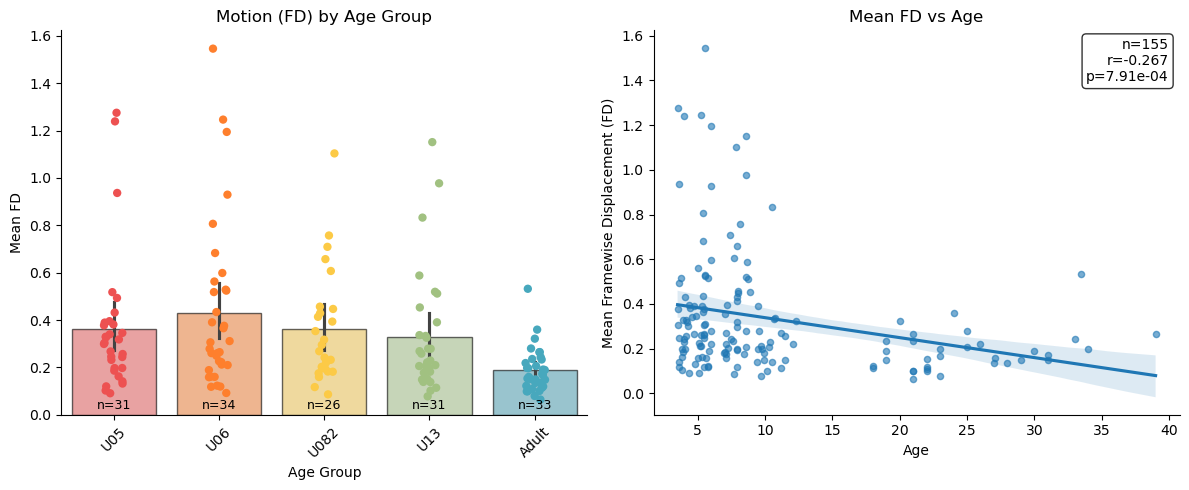

In [23]:

# Analyze motion data (mean_FD) across age groups
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mean FD vs Age scatter plot
ax = axes[1]
mask = par_df[['Age', 'mean_FD']].notnull().all(axis=1)
x = par_df.loc[mask, 'Age']
y = par_df.loc[mask, 'mean_FD']
sns.regplot(data=par_df.loc[mask], x='Age', y='mean_FD', ax=ax,
            scatter_kws={'s': 20, 'alpha': 0.6}, ci=95)
r_overall, p_overall = stats.pearsonr(x, y)
n_overall = mask.sum()
ax.set_title('Mean FD vs Age')
ax.text(0.98, 0.98, f'n={n_overall}\nr={r_overall:.3f}\np={p_overall:.2e}',
        transform=ax.transAxes, ha='right', va='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_ylabel('Mean Framewise Displacement (FD)')

# Mean FD by age group boxplot
ax = axes[0]
sns.barplot(data=par_df, x='AgeGroup1', y='mean_FD', ax=ax, palette=helper.get_palette7_rainbow(), alpha=0.6, edgecolor='black')
sns.stripplot(data=par_df, x='AgeGroup1', y='mean_FD', ax=ax, palette=helper.get_palette7_rainbow(),
              size=6, alpha=1)
# Plot on each bar the number of participants in that age group
age_group_counts = par_df['AgeGroup1'].value_counts().to_dict()
for p,age_group in zip(ax.patches, ['U05','U06','U082','U13','Adult']):
    x = p.get_x() + p.get_width() / 2
    count = age_group_counts.get(age_group, 0)
    ax.text(x, 0.01, f'n={count}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Age Group')
ax.set_ylabel('Mean FD')
ax.set_title('Motion (FD) by Age Group')
ax.tick_params(axis='x', rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


# Analysis of ISC, IDE (TPHATE_DiffOp), and PCA across age groups

ISC analysis - Subjects included: 154


/tmp/ipykernel_2046964/775832986.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub_df, x='AgeGroup', y='ISC_mean', ax=ax,
/tmp/ipykernel_2046964/775832986.py:28: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.stripplot(data=sub_df, x='AgeGroup', y='ISC_mean', ax=ax,
/tmp/ipykernel_2046964/775832986.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize='small', loc='lower right', ncol=1)


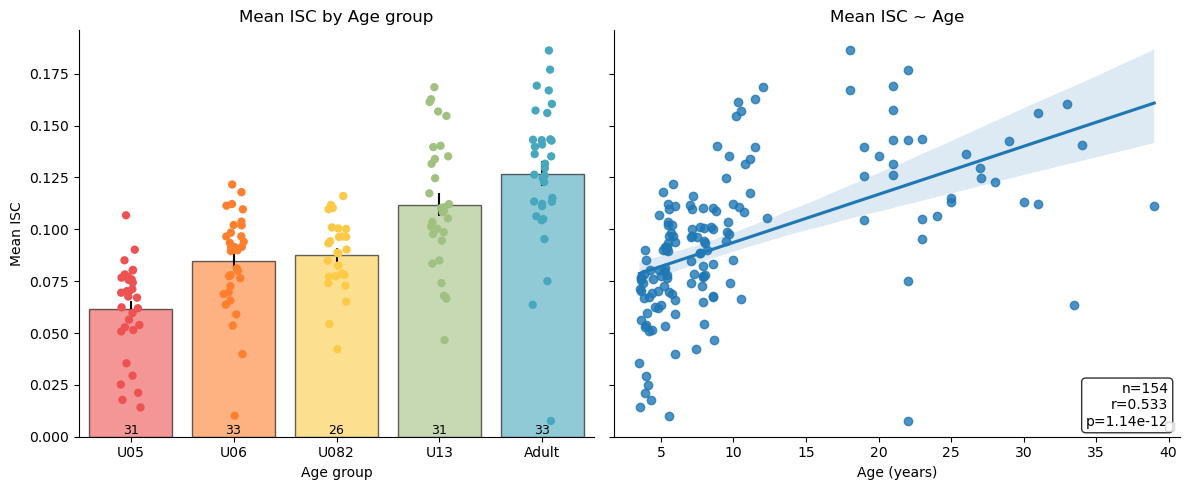

In [21]:

# Subject-level ISC analysis: barplot by AgeGroup (left) and partial scatter/regression controlling for motion (right)
task = 'pixar'
measure = 'ISC'
df_regional = results_df[(results_df['task'] == task) & (results_df['measure'] == measure)].copy()
sub_mean = df_regional.groupby('subject')['score'].mean().reset_index().rename(columns={'score': 'ISC_mean'})

# Merge age and motion from par_df
meta = par_df[['participant_id', 'mean_FD', 'AgeGroup1', 'Age']].rename(
    columns={'participant_id': 'subject', 'Age': 'Age', 'AgeGroup1': 'AgeGroup'})
sub_df = sub_mean.merge(meta, on='subject', how='left').dropna(subset=['ISC_mean', 'mean_FD', 'AgeGroup'])
print(f"ISC analysis - Subjects included: {len(sub_df)}")

# Compute group stats for bar plot
age_order = ['U05', 'U06', 'U082', 'U13', 'Adult']
grp = sub_df.groupby('AgeGroup').agg(mean_ISC=('ISC_mean', 'mean'),
                                     sem_ISC=('ISC_mean', 'sem'),
                                     n=('ISC_mean', 'count')).reindex(age_order).dropna(how='all')

# Plotting: left = barplot of mean ISC per AgeGroup, right = partial scatter/regression (control mean_FD)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1.1]}, sharey=True)

# Left: barplot with errorbars and sample sizes
ax = axes[0]
x = np.arange(len(grp))
bar_cols = helper.get_palette7_rainbow()
ax.bar(x, grp['mean_ISC'], yerr=grp['sem_ISC'], color=bar_cols, edgecolor='k', alpha=0.6)
# add stripplot of individual points
sns.stripplot(data=sub_df, x='AgeGroup', y='ISC_mean', ax=ax, 
              order=age_order, palette=bar_cols, size=6, alpha=1)
ax.set_xticks(x)
ax.set_xticklabels(grp.index)
ax.set_xlabel('Age group')
ax.set_ylabel('Mean ISC')
ax.set_title('Mean ISC by Age group')
# Annotate counts
for xi, (m, n) in enumerate(zip(grp['mean_ISC'], grp['n'])):
    ax.text(xi, 0, f"{int(n)}", ha='center', va='bottom', fontsize=9)

# Right:  scatter/regression 
ax2 = axes[1]
sns.regplot(data=sub_df, x='Age', y='ISC_mean', ax=ax2)
# Print correlation stats
r_age, p_age = stats.pearsonr(sub_df['Age'], sub_df['ISC_mean'])
n_age = len(sub_df)
ax2.text(0.98, 0.02, f'n={n_age}\nr={r_age:.3f}\np={p_age:.2e}',
         transform=ax2.transAxes, ha='right', va='bottom', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax2.set_xlabel('Age (years)')
ax2.set_ylabel('')
ax2.set_title('Mean ISC ~ Age')
ax2.legend(fontsize='small', loc='lower right', ncol=1)
sns.despine()
plt.tight_layout()
plt.show()


TPHATE_DiffOp: Subjects in analysis: 154


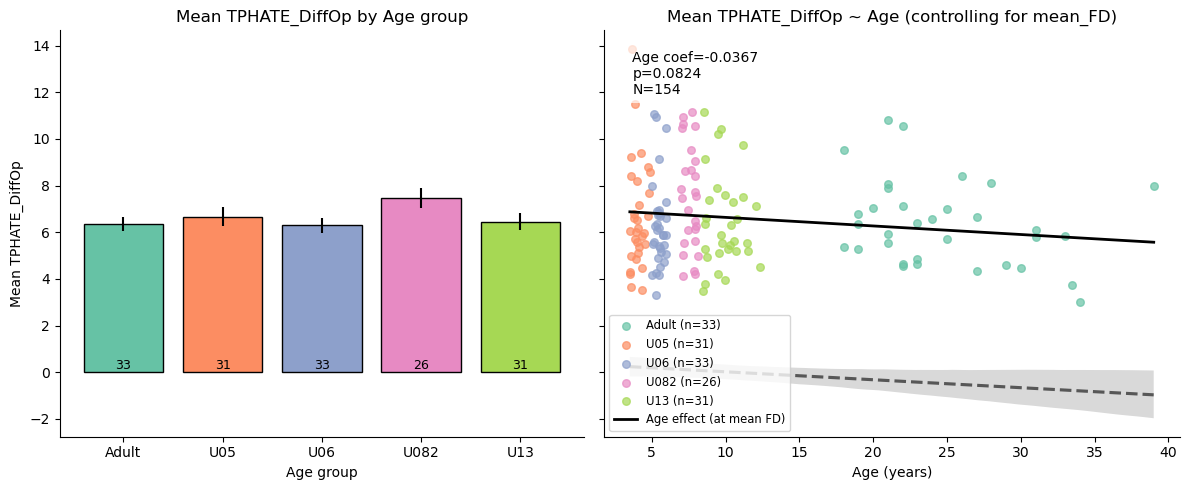

PCA: Subjects in analysis: 154


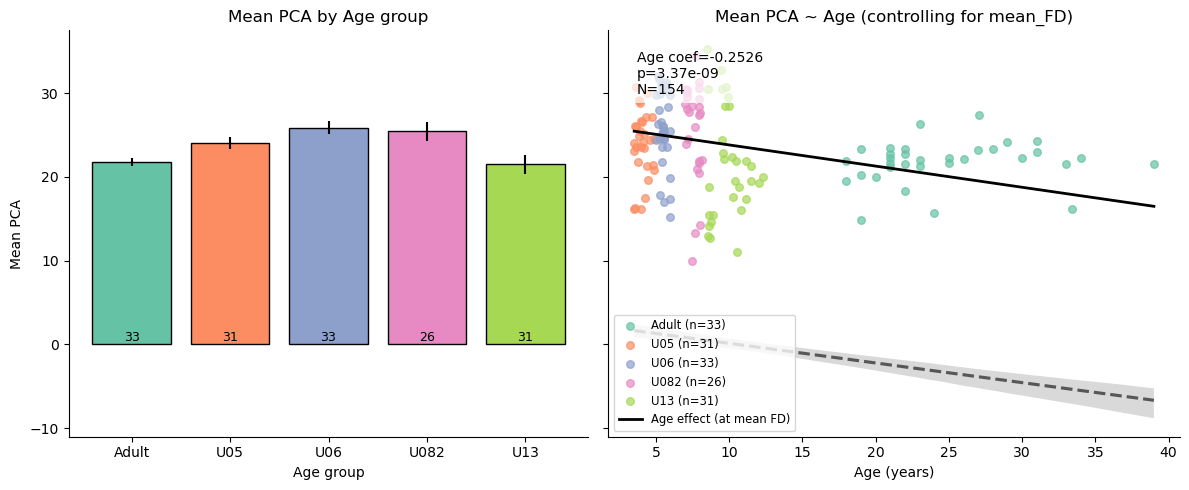

In [8]:
# Subject-level analyses for TPHATE_DiffOp (IDE) and PCA (mean across parcels)
task = 'pixar'
measures_to_run = ['TPHATE_DiffOp', 'PCA']

for measure in measures_to_run:
    df_regional = results_df[(results_df['task'] == task) & (results_df['measure'] == measure)].copy()
    sub_mean = df_regional.groupby('subject')['score'].mean().reset_index().rename(columns={'score': f'{measure}_mean'})

    # Merge age and motion from par_df
    meta = par_df[['participant_id', 'mean_FD', 'AgeGroup1', 'Age']].rename(
        columns={'participant_id': 'subject', 'Age': 'Age', 'AgeGroup1': 'AgeGroup'})
    sub_df = sub_mean.merge(meta, on='subject', how='left').dropna(subset=[f'{measure}_mean', 'mean_FD', 'AgeGroup'])
    print(f"{measure}: Subjects in analysis: {len(sub_df)}")

    # Group stats for bar plot
    age_order = sorted(sub_df.AgeGroup.unique())
    grp = sub_df.groupby('AgeGroup').agg(mean_val=(f'{measure}_mean', 'mean'),
                                         sem_val=(f'{measure}_mean', 'sem'),
                                         n=('subject', 'count')).reindex(age_order).dropna(how='all')

    # Plotting: left = barplot by AgeGroup, right = partial scatter/regression controlling for mean_FD
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1.1]}, sharey=True)
    ax = axes[0]
    x = np.arange(len(grp))
    bar_cols = sns.color_palette('Set2', n_colors=len(grp))
    ax.bar(x, grp['mean_val'], yerr=grp['sem_val'], color=bar_cols, edgecolor='k')
    ax.set_xticks(x)
    ax.set_xticklabels(grp.index)
    ax.set_xlabel('Age group')
    ax.set_ylabel(f'Mean {measure}')
    ax.set_title(f'Mean {measure} by Age group')
    for xi, (m, n) in enumerate(zip(grp['mean_val'], grp['n'])):
        ax.text(xi, 0, f"{int(n)}", ha='center', va='bottom', fontsize=9)

    # Right: partial relationship measure_mean ~ Age controlling for mean_FD
    model = smf.ols(f'{measure}_mean ~ Age + mean_FD', data=sub_df).fit()
    # Residualize y by mean_FD for a partial-plot feel
    res_y = smf.ols(f'{measure}_mean ~ mean_FD', data=sub_df).fit().resid

    ax2 = axes[1]
    palette_local = {g: c for g, c in zip(age_order, sns.color_palette('Set2', n_colors=len(age_order)))}
    for grp_name, dfg in sub_df.groupby('AgeGroup'):
        ax2.scatter(dfg['Age'], dfg[f'{measure}_mean'], label=f'{grp_name} (n={len(dfg)})', alpha=0.7, s=30,
                    color=palette_local.get(grp_name, 'gray'))

    # Predict at mean mean_FD across Age grid
    age_grid = np.linspace(sub_df['Age'].min(), sub_df['Age'].max(), 100)
    pred_df = pd.DataFrame({'Age': age_grid, 'mean_FD': sub_df['mean_FD'].mean()})
    pred = model.predict(pred_df)
    ax2.plot(age_grid, pred, color='k', linewidth=2, label='Age effect (at mean FD)')

    # Residualized regression line for clarity
    sns.regplot(x=sub_df['Age'], y=res_y, scatter=False, ci=95, ax=ax2, color='k', 
                line_kws={'linestyle': '--', 'alpha': 0.6})

    coef_age = model.params.get('Age', np.nan)
    p_age = model.pvalues.get('Age', np.nan)
    ax2.text(0.05, 0.95, f'Age coef={coef_age:.4f}\np={p_age:.3g}\nN={len(sub_df)}',
             transform=ax2.transAxes, ha='left', va='top', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax2.set_xlabel('Age (years)')
    ax2.set_ylabel('')
    ax2.set_title(f'Mean {measure} ~ Age (controlling for mean_FD)')
    ax2.legend(fontsize='small', loc='lower left')
    sns.despine()
    plt.tight_layout()
    plt.show()


In [5]:
results_df.head()

,task,subject,AgeGroup,Age,measure,score
region_name,,,,,,
17Networks_LH_VisCent_ExStr_1,pixar,sub-pixar001,U05,4.774812,TPHATE_DiffOp,11.0
17Networks_LH_VisCent_ExStr_2,pixar,sub-pixar001,U05,4.774812,TPHATE_DiffOp,10.0
17Networks_LH_VisCent_ExStr_3,pixar,sub-pixar001,U05,4.774812,TPHATE_DiffOp,9.0
17Networks_LH_VisCent_ExStr_4,pixar,sub-pixar001,U05,4.774812,TPHATE_DiffOp,12.0
17Networks_LH_VisCent_ExStr_5,pixar,sub-pixar001,U05,4.774812,TPHATE_DiffOp,11.0


In [11]:
# Aggregate ISC and TPHATE_DiffOp (IDE) across participants by AgeGroup and plot with the helper
task = 'pixar'
measures = {'ISC': 'ISC', 'TPHATE_DiffOp': 'IDE'}
REGION_ORDER = results_df['region_name'].values[:400]
results_dfa = results_df[results_df['task'] == task]
df = results_dfa[results_dfa['measure'].isin(measures.keys())].copy()
age_order = ['U05', 'U06', 'U082', 'U13', 'Adult']

# Mean score per region x AgeGroup x measure
mean_by = df.groupby(['AgeGroup', 'measure', 'region_name'])['score'].agg(lambda x: x.mean(skipna=True)).reset_index()

age_groups = ['U05','U06','U082','U13','Adult']# sorted(mean_by['AgeGroup1'].unique())
data_arrs = []
titles = []
img_fns = []

# Create a data array (Series indexed by region_name) for each AgeGroup x measure
for m in measures.keys():  # order: ISC then TPHATE_DiffOp
    for age in age_groups:
        s = mean_by[(mean_by['AgeGroup'] == age) & (mean_by['measure'] == m)].set_index('region_name').reindex(REGION_ORDER)['score']
        data_arrs.append(s)
        titles.append(f"{age} {measures[m]}")
        img_fns.append(f'PartlyCloudy/plots/{task}_{age}_{m}.png')

n_rows = len(age_groups)  # each row will contain ISC and IDE for one AgeGroup
# Output path for the compiled figure
output_path = os.path.join('main_plots/partlycloudy_agegroup_ISC_TPHATE_surface_grid.pdf')

# Call the plotting helper
helper.compile_surface_plots_to_grid_by_rows(img_fns, data_arrs, output_path, n_rows=2, 
                                             surf_type='fslr', target_density='32k', method='linear',  
                                             atlas='Schaefer', rerun=True, cmaps_per_row=['magma', viridis_white],
                                             cbar_ranges_per_row=[[0.0, 0.3], [1, 16]], 
                                             cbar_labels_per_row=['ISC', 'IDE'],
                                             titles=titles)




Rerunning surface plot generation for 10 images.
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U05_ISC.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U06_ISC.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U082_ISC.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U13_ISC.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_Adult_ISC.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: PartlyCloudy/plots/pixar_U05_TPHATE_DiffOp.png
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nile

'main_plots/partlycloudy_agegroup_ISC_TPHATE_surface_grid.pdf'

# Run IDE x ISC correlation analysis across subjects

In [4]:
pivot_df = results_df[results_df['measure'].isin(['TPHATE_DiffOp', 'ISC'])].copy()
pivot_df = pivot_df.pivot_table(index=['subject','region_name'], columns='measure', values='score').reset_index()
pivot_df.head()

measure,subject,region_name,ISC,TPHATE_DiffOp
0,sub-pixar001,17Networks_LH_ContA_Cingm_1,0.062296,5.0
1,sub-pixar001,17Networks_LH_ContA_IPS_1,0.105055,12.0
2,sub-pixar001,17Networks_LH_ContA_IPS_2,0.033634,10.0
3,sub-pixar001,17Networks_LH_ContA_IPS_3,0.063811,11.0
4,sub-pixar001,17Networks_LH_ContA_IPS_4,-0.012885,10.0


In [ ]:
df_corr = pd.DataFrame(columns=['subject','rho','pval','zscore','movie_FD','Age','AgeGroup1','sex'])
for s in pivot_df['subject'].unique():
    temp = pivot_df[pivot_df['subject'] == s]
    if len(temp) < 400 or len(par_df[par_df['participant_id'] == s])==0:
        continue
    ide_movie = temp['TPHATE_DiffOp'].values
    isc = temp['ISC'].values
    pval, obs, zsc = stats_helpers.permute_pattern(ide_movie, isc, n_permutations=1000, random_state=None)
    df_corr.loc[len(df_corr)] = [s, obs, pval, zsc, 
                                par_df[par_df['participant_id'] == s]['mean_FD'].values[0],
                                par_df[par_df['participant_id'] == s]['Age'].values[0],
                                par_df[par_df['participant_id'] == s]['AgeGroup1'].values[0],
                                par_df[par_df['participant_id'] == s]['Gender'].values[0],
                               ]
df_corr.to_csv(f'{pcu.get_results_dir()}/ISC_TPHATE_DiffOp_corr.csv', index=False)
    

In [13]:
df_corr = pd.read_csv(f'{pcu.get_results_dir()}/ISC_TPHATE_DiffOp_corr.csv', index_col=0)

In [8]:
def get_age_groupings(age):
    if age < 3:
        return 'U03'
    elif age < 4:
        return 'U04'
    elif age < 5:
        return 'U05'    
    elif age < 6:
        return 'U06'
    elif age < 7:
        return 'U07'
    elif age < 8:
        return 'U08'
    elif age < 10:
        return 'U10'
    elif age < 13:
        return 'U13'
    else:
        return 'Adult'




/tmp/ipykernel_3128737/4000701872.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_corr, x='AgeGroup', y='zscore', order=age_order,palette=helper.get_palette7_rainbow(), edgecolor='k', linewidth=2,alpha=0.8)
/tmp/ipykernel_3128737/4000701872.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_corr, x='AgeGroup', y='zscore', order=age_order, palette=helper.get_palette7_rainbow(),edgecolor='k',linewidth=0.8,


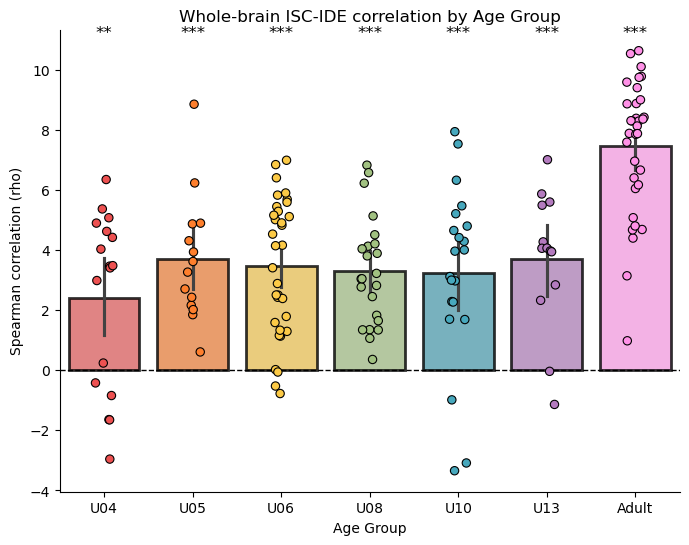

In [28]:
# plot as barplot by AgeGroup1
df_corr['AgeGroup'] = [get_age_groupings(a) for a in df_corr['Age']]
age_order = ['U04','U05', 'U06', 'U08', 'U10','U13', 'Adult']
plt.figure(figsize=(8,6))
sns.barplot(data=df_corr, x='AgeGroup', y='zscore', order=age_order,palette=helper.get_palette7_rainbow(), edgecolor='k', linewidth=2,alpha=0.8)
sns.stripplot(data=df_corr, x='AgeGroup', y='zscore', order=age_order, palette=helper.get_palette7_rainbow(),edgecolor='k',linewidth=0.8,
              size=6, alpha=1)
# Add statistics per group relative to 0
for i, age_grp in enumerate(age_order):
    data_grp = df_corr[df_corr['AgeGroup'] == age_grp]['zscore'].dropna()
    if len(data_grp) == 0:
        continue
    stat, p_val = scipy.stats.ttest_1samp(data_grp, 0, alternative='two-sided')
    # Annotate significance
    y_max = data_grp.max()
    y_min = data_grp.min()
    y_pos = y_max + (y_max - y_min) * 0.1
    if p_val < 0.001:
        sig_label = '***'
    elif p_val < 0.01:
        sig_label = '**'
    elif p_val < 0.05:
        sig_label = '*'
    else:
        sig_label = 'n.s.'
    plt.text(i, 11, sig_label, ha='center', va='bottom', fontsize=12)

plt.xlabel('Age Group')
plt.ylabel('Spearman correlation (rho)')
plt.title('Whole-brain ISC-IDE correlation by Age Group')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
sns.despine()




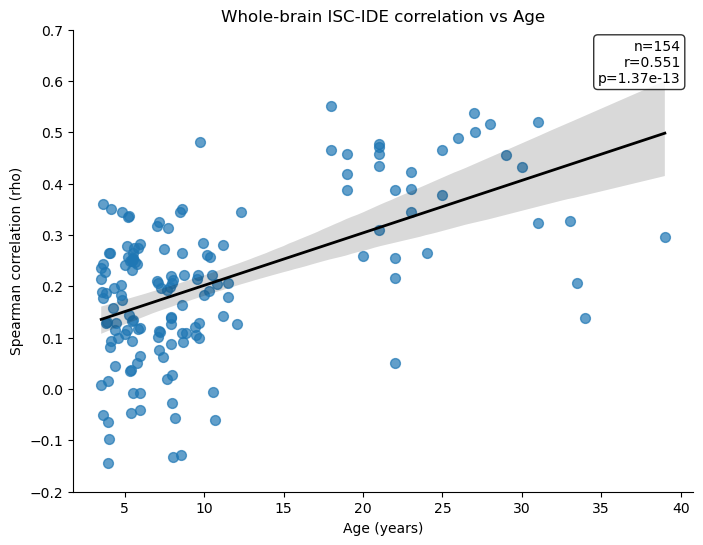

In [57]:
# plot correlation between ISC-IDE correlation and Age
plt.figure(figsize=(8,6))
sns.regplot(data=df_corr, x='Age', y='r', scatter_kws={'s': 50, 'alpha': 0.7}, line_kws={'color': 'k', 'linewidth':2})
r_overall, p_overall = stats.pearsonr(df_corr['Age'], df_corr['r'])
n_overall = len(df_corr)
plt.title('Whole-brain ISC-IDE correlation vs Age')
plt.text(0.98, 0.98, f'n={n_overall}\nr={r_overall:.3f}\np={p_overall:.2e}',
        transform=plt.gca().transAxes, ha='right', va='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Age (years)')
plt.ylabel('Spearman correlation (rho)')
plt.ylim(-0.2, 0.7)
sns.despine()

In [11]:
temp=results_df.groupby(['measure','AgeGroup','subject']).mean(numeric_only=True).reset_index() 
anova_model = smf.ols('score ~ C(AgeGroup)', data=temp[temp['measure']=='TPHATE_DiffOp']).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(AgeGroup),25.833199,4.0,1.555339,0.189247
Residual,618.698801,149.0,NaN,NaN


In [14]:
df_corr.head()

,rho,pval,zscore,movie_FD,Age,AgeGroup1,sex
subject,,,,,,,
sub-pixar001,0.183780,0.000999,3.622246,0.389254,4.774812,U05,M
sub-pixar002,0.190115,0.000999,3.939167,0.345567,4.856947,U05,F
sub-pixar003,0.108883,0.024975,2.164586,0.327122,4.153320,U05,F
sub-pixar004,0.122102,0.016983,2.429890,0.381298,4.473648,U05,F
sub-pixar005,0.305272,0.000999,6.238120,0.131736,4.837782,U05,F


In [ ]:
stats.ttest_1samp(df_corr[df_corr['AgeGroup1']=='U05']['zscore'].values, 0)

TtestResult(statistic=6.32122670820569, pvalue=5.701131211118729e-07, df=30)

In [15]:
anova_model = smf.ols('zscore ~ C(AgeGroup1)', data=df_corr).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(AgeGroup1),460.505985,4.0,20.54718,1.682519e-13
Residual,834.851696,149.0,NaN,NaN


# Plotting IDE age isc correlations

In [19]:
import parcelwise_regressions as pwr
REGION_ORDER = results_df['region_name'].values[:400]
# Pivot the results dataframe to have TPHATE_DiffOp and ISC as columns
results_df1 = results_df.pivot_table(index=['subject','region_name','task','AgeGroup','Age'], 
                                      columns='measure', values='score').reset_index()

dataframe = pwr.join_results_participant_info(results_df1, par_df, 'partlycloudy')
# resort the dataframe to have regions in the right order

In [8]:
dataframe.head()

,subject,region_name,task,AgeGroup,Age,ISC,PCA,TPHATE_DiffOp,mean_FD,sex
0,sub-pixar001,17Networks_LH_ContA_Cingm_1,pixar,U05,4.774812,0.062296,19.0,5.0,0.389254,M
1,sub-pixar001,17Networks_LH_ContA_IPS_1,pixar,U05,4.774812,0.105055,21.0,12.0,0.389254,M
2,sub-pixar001,17Networks_LH_ContA_IPS_2,pixar,U05,4.774812,0.033634,14.0,10.0,0.389254,M
3,sub-pixar001,17Networks_LH_ContA_IPS_3,pixar,U05,4.774812,0.063811,18.0,11.0,0.389254,M
4,sub-pixar001,17Networks_LH_ContA_IPS_4,pixar,U05,4.774812,-0.012885,20.0,10.0,0.389254,M


In [20]:
formula = f"TPHATE_DiffOp ~ ISC * Age +  sex + mean_FD"
results = pwr.run_regression_analyses(dataframe, 'Age', 'TPHATE_DiffOp', formula, ['ISC*Age','ISC', 'sex', 'mean_FD'], 
                                output_directory=None, root_filename=None, region_order=REGION_ORDER, 
                                title='', plot=0, verbose=1)
v = results.set_index('region_name').reindex(REGION_ORDER)[f'r2'].values

Using formula: TPHATE_DiffOp ~ ISC * Age +  sex + mean_FD


In [25]:
results['sig_ISC_Age_fdr'].sum()

0

In [9]:
f= "TPHATE_DiffOp ~ Age + ISC + sex + mean_FD"

a = stats_helpers.parcelwise_regression(dataframe, "Age", yname="TPHATE_DiffOp", formula=f, 
                         region_order=REGION_ORDER, alpha=0.05, fdr_method='fdr_bh')

Using formula: TPHATE_DiffOp ~ Age + ISC + sex + mean_FD


In [14]:
helper.generate_surface_plot( 
                a['r2'].values,
                image_fn=None,#"main_plots/HBN_age_predicts_ide_movieTP_r2_masked.pdf",
                atlas='Schaefer',
                cmap='magma',
                cbar_range=[0,0.35],
                surf_type='fslr',
                target_density='32k',
                method='linear',
                include_cbar=True,
                title=rf'Model R^2',
                threshold=None,
                mask_medial_wall=True
            )

to_plot = ['Age', 'ISC']
cmaps = [helper.diverging_colormap_gpu(),helper.diverging_colormap_gpu(), 'magma']
for var,cmap,thr in zip(to_plot, cmaps, [None, 4]):
    sig_mask = a.set_index('region_name').reindex(REGION_ORDER)[f'sig_{var}_fdr'].values
    #sig_mask = np.ones_like(a.set_index('region_name').reindex(REGION_ORDER)[f'coef_{var}'].values)
    coef_masked = a.set_index('region_name').reindex(REGION_ORDER)[f'coef_{var}'].values
    if var == 'Age':
         coef_masked = coef_masked*sig_mask
    
    t_mask = a.set_index('region_name').reindex(REGION_ORDER)[f'tstat_{var}'].values #* sig_mask

    cbar_range, this_cmap = helper.determine_colorbar_range(coef_masked, cmap)
    
    helper.generate_surface_plot( 
                coef_masked,
                image_fn=f"main_plots/partlycloudy_age_predicts_ide_{var}_coef_masked.pdf",
                atlas='Schaefer',
                cmap=this_cmap,
                cbar_range=cbar_range,
                surf_type='fslr',
                target_density='32k',
                method='linear',
                include_cbar=True,
                title=rf'$\beta$_{var}',
                threshold=thr,
                mask_medial_wall=True
            )
    
    # cbar_range, this_cmap = helper.determine_colorbar_range(t_mask, cmap)
    # helper.generate_surface_plot( 
    #             t_mask,
    #             image_fn=None,#f"main_plots/HBN_age_predicts_ide_movieTP_{var}_tstat_masked.pdf",
    #             atlas='Schaefer',
    #             cmap=this_cmap,
    #             cbar_range=cbar_range,
    #             surf_type='fslr',
    #             target_density='32k',
    #             method='linear',
    #             include_cbar=True,
    #             title=rf'tstat_{var}',
    #             threshold=None,
    #             mask_medial_wall=True
    #         )

[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: None
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: main_plots/partlycloudy_age_predicts_ide_Age_coef_masked.pdf
[get_dataset_dir] Dataset found in /gpfs/radev/home/elb77/nilearn_data/schaefer_2018
Generated surface plot: main_plots/partlycloudy_age_predicts_ide_ISC_coef_masked.pdf


In [6]:
arr = np.array([np.nan])
len(arr)

1